# 06 — SMOTE Distortion

This notebook examines whether SMOTE affects how SHAP interprets the model, not just how the model performs.

To do this, each model is trained in three different ways:

SMOTE (resampled data)
class_weight (loss reweighting on original data)
raw (no imbalance handling)

The raw version serves as a true baseline. Class weighting already changes the learning process, so it cannot be treated as neutral.

By comparing all three setups, the aim is to separate the specific effect of SMOTE from the broader impact of handling class imbalance.

**Steps:**

1. Load trained models and test data
2. Compute SHAP importance for all model versions
3. Compare feature rankings (Spearman, rank shift, top-k overlap)
4. Identify features affected by SMOTE
5. Case study: local SHAP comparison and feature masking

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import os
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

In [2]:
X_train_orig = pd.read_csv('../data/processed/X_train.csv')
y_train_orig = pd.read_csv('../data/processed/y_train.csv').squeeze()

X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# SMOTE-trained models from notebooks 02 and 03
rf_smote  = joblib.load('../results/rf_model.pkl')
xgb_smote = joblib.load('../results/xgb_model.pkl')

print('data and smote models loaded.')
print(f'train size: {X_train_orig.shape}, fraud rate: {y_train_orig.mean():.4f}')

data and smote models loaded.
train size: (413378, 421), fraud rate: 0.0350


## Train reference models

Two reference versions: class_weight (reweights the loss function) and raw (no correction at all). Same hyperparameters as the SMOTE models throughout.

In [3]:
# RF with class_weight
rf_ref = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_leaf=1,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_ref.fit(X_train_orig, y_train_orig)
print('rf_ref (class_weight) done')

rf_ref (class_weight) done


In [4]:
# RF with no correction
rf_raw = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_leaf=1,
    class_weight=None, random_state=42, n_jobs=-1
)
rf_raw.fit(X_train_orig, y_train_orig)
print('rf_raw (no correction) done')

rf_raw (no correction) done


In [5]:
ratio = (y_train_orig == 0).sum() / (y_train_orig == 1).sum()

# XGBoost with scale_pos_weight
xgb_ref = XGBClassifier(
    learning_rate=0.1, max_depth=8, n_estimators=200,
    scale_pos_weight=ratio, eval_metric='aucpr',
    random_state=42, n_jobs=-1
)
xgb_ref.fit(X_train_orig, y_train_orig)
print('xgb_ref (scale_pos_weight) done')

xgb_ref (scale_pos_weight) done


In [6]:
# XGBoost with no correction, scale_pos_weight=1 disables reweighting
xgb_raw = XGBClassifier(
    learning_rate=0.1, max_depth=8, n_estimators=200,
    scale_pos_weight=1, eval_metric='aucpr',
    random_state=42, n_jobs=-1
)
xgb_raw.fit(X_train_orig, y_train_orig)
print('xgb_raw (no correction) done')

xgb_raw (no correction) done


## SHAP values: balanced sample, all 6 models

Using 75 fraud + 75 legit = 150 instances. Went with 150 instead of the original 60 because ranking comparisons across 421 features need a bigger sample to be stable.

In [7]:
fraud_idx = y_test[y_test == 1].index[:75].tolist()
legit_idx = y_test[y_test == 0].index[:75].tolist()
X_s = X_test.loc[fraud_idx + legit_idx].reset_index(drop=True)

print(f'sample size: {len(X_s)}')
print(f'fraud: {len(fraud_idx)}, legit: {len(legit_idx)}')

sample size: 150
fraud: 75, legit: 75


In [8]:
def shap_importance(model, X):
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X, check_additivity=False)
    if isinstance(shap_vals, list): shap_vals = shap_vals[1]
    if shap_vals.ndim == 3: shap_vals = shap_vals[:,:,1]
    return pd.Series(np.abs(shap_vals).mean(axis=0), index=X.columns)

In [9]:
print('computing SHAP for all 6 models')

print('rf smote...')
rf_smote_imp  = shap_importance(rf_smote, X_s)
print('rf ref...')
rf_ref_imp    = shap_importance(rf_ref,   X_s)
print('rf raw...')
rf_raw_imp    = shap_importance(rf_raw,   X_s)

print('xgb smote...')
xgb_smote_imp = shap_importance(xgb_smote, X_s)
print('xgb ref...')
xgb_ref_imp   = shap_importance(xgb_ref,   X_s)
print('xgb raw...')
xgb_raw_imp   = shap_importance(xgb_raw,   X_s)

print('all done.')

computing SHAP for all 6 models, this takes a while...
rf smote...
rf ref...
rf raw...
xgb smote...
xgb ref...
xgb raw...
all done.


## How different are the rankings?

Three pairwise comparisons per model. The key one is SMOTE vs raw: that's the cleanest test of whether SMOTE itself is causing the shift.

In [10]:
corr_rf_smote_ref, _ = spearmanr(rf_smote_imp,  rf_ref_imp)
corr_rf_smote_raw, _ = spearmanr(rf_smote_imp,  rf_raw_imp)
corr_rf_ref_raw,   _ = spearmanr(rf_ref_imp,    rf_raw_imp)

corr_xgb_smote_ref, _ = spearmanr(xgb_smote_imp, xgb_ref_imp)
corr_xgb_smote_raw, _ = spearmanr(xgb_smote_imp, xgb_raw_imp)
corr_xgb_ref_raw,   _ = spearmanr(xgb_ref_imp,   xgb_raw_imp)

print('RF Spearman:')
print(f'  SMOTE vs class_weight : {corr_rf_smote_ref:.4f}')
print(f'  SMOTE vs raw          : {corr_rf_smote_raw:.4f}')
print(f'  class_weight vs raw   : {corr_rf_ref_raw:.4f}')
print()
print('XGBoost Spearman:')
print(f'  SMOTE vs class_weight : {corr_xgb_smote_ref:.4f}')
print(f'  SMOTE vs raw          : {corr_xgb_smote_raw:.4f}')
print(f'  class_weight vs raw   : {corr_xgb_ref_raw:.4f}')

RF Spearman:
  SMOTE vs class_weight : 0.8532
  SMOTE vs raw          : 0.5933
  class_weight vs raw   : 0.6590

XGBoost Spearman:
  SMOTE vs class_weight : 0.7924
  SMOTE vs raw          : 0.7890
  class_weight vs raw   : 0.8775


In [11]:
def rank_shift(imp_a, imp_b, n=20):
    rank_a    = imp_a.rank(ascending=False)
    rank_b    = imp_b.rank(ascending=False)
    top_feats = imp_a.nlargest(n).index
    return (rank_a[top_feats] - rank_b[top_feats]).abs()

rf_shift_smote_ref  = rank_shift(rf_smote_imp,  rf_ref_imp)
rf_shift_smote_raw  = rank_shift(rf_smote_imp,  rf_raw_imp)
rf_shift_ref_raw    = rank_shift(rf_ref_imp,    rf_raw_imp)

xgb_shift_smote_ref = rank_shift(xgb_smote_imp, xgb_ref_imp)
xgb_shift_smote_raw = rank_shift(xgb_smote_imp, xgb_raw_imp)
xgb_shift_ref_raw   = rank_shift(xgb_ref_imp,   xgb_raw_imp)

print('RF mean rank shift (top-20):')
print(f'  SMOTE vs class_weight : {rf_shift_smote_ref.mean():.2f}')
print(f'  SMOTE vs raw          : {rf_shift_smote_raw.mean():.2f}')
print(f'  class_weight vs raw   : {rf_shift_ref_raw.mean():.2f}')
print()
print('XGBoost mean rank shift (top-20):')
print(f'  SMOTE vs class_weight : {xgb_shift_smote_ref.mean():.2f}')
print(f'  SMOTE vs raw          : {xgb_shift_smote_raw.mean():.2f}')
print(f'  class_weight vs raw   : {xgb_shift_ref_raw.mean():.2f}')

RF mean rank shift (top-20):
  SMOTE vs class_weight : 36.95
  SMOTE vs raw          : 83.25
  class_weight vs raw   : 47.25

XGBoost mean rank shift (top-20):
  SMOTE vs class_weight : 50.45
  SMOTE vs raw          : 52.25
  class_weight vs raw   : 2.20


In [12]:
# which features moved the most; SMOTE vs raw is the main comparison
print('XGB — biggest movers (SMOTE vs raw):')
print(xgb_shift_smote_raw.nlargest(10))
print()
print('RF — biggest movers (SMOTE vs raw):')
print(rf_shift_smote_raw.nlargest(10))

XGB — biggest movers (SMOTE vs raw):
V90     197.0
V288    195.0
V282    189.0
V280    129.0
V306    102.0
V317     81.0
V313     42.0
V308     36.0
C12      22.0
C13      10.0
dtype: float64

RF — biggest movers (SMOTE vs raw):
V265     342.0
V264     232.0
V279     227.0
V258     192.0
V280      91.0
V283      88.0
V318      75.0
V282      61.0
C8        54.0
card6     51.0
dtype: float64


## Top-10 feature overlap

In [13]:
def top10_overlap(imp_a, imp_b):
    top_a  = set(imp_a.nlargest(10).index)
    top_b  = set(imp_b.nlargest(10).index)
    shared = top_a & top_b
    return len(shared), top_a - top_b, top_b - top_a

print('=== XGBoost top-10 overlap ===')
n, a_only, b_only = top10_overlap(xgb_smote_imp, xgb_raw_imp)
print(f'SMOTE vs raw          : {n}/10 shared')
print(f'  SMOTE-only : {a_only}')
print(f'  raw-only   : {b_only}')
print()
n, a_only, b_only = top10_overlap(xgb_smote_imp, xgb_ref_imp)
print(f'SMOTE vs class_weight : {n}/10 shared')
print(f'  SMOTE-only       : {a_only}')
print(f'  class_weight-only: {b_only}')
print()
n, a_only, b_only = top10_overlap(xgb_ref_imp, xgb_raw_imp)
print(f'class_weight vs raw   : {n}/10 shared')

=== XGBoost top-10 overlap ===
SMOTE vs raw          : 6/10 shared
  SMOTE-only : {'V317', 'C12', 'V308', 'V306'}
  raw-only   : {'TransactionID', 'V70', 'V294', 'C13'}

SMOTE vs class_weight : 6/10 shared
  SMOTE-only       : {'V317', 'C12', 'V308', 'V306'}
  class_weight-only: {'C13', 'V70', 'V294', 'card1'}

class_weight vs raw   : 9/10 shared


## Is distortion concentrated in certain feature types?

Using SMOTE vs raw as the comparison here since that's the most meaningful baseline.

In [14]:
def fgroup(name):
    if name.startswith('V'):            return 'V'
    if name.startswith('C'):            return 'C'
    if name.lower().startswith('card'): return 'card'
    if name.lower().startswith('id_'):  return 'id'
    if name.startswith('M'):            return 'M'
    return 'other'

rf_change  = (rf_smote_imp  - rf_raw_imp).abs()
xgb_change = (xgb_smote_imp - xgb_raw_imp).abs()

rf_change_df = pd.DataFrame({
    'change': rf_change.values,
    'group':  [fgroup(f) for f in rf_change.index]
}, index=rf_change.index)

xgb_change_df = pd.DataFrame({
    'change': xgb_change.values,
    'group':  [fgroup(f) for f in xgb_change.index]
}, index=xgb_change.index)

print('RF — mean SHAP change by group (SMOTE vs raw):')
print(rf_change_df.groupby('group')['change'].mean().sort_values(ascending=False).round(5))
print()
print('XGB — mean SHAP change by group (SMOTE vs raw):')
print(xgb_change_df.groupby('group')['change'].mean().sort_values(ascending=False).round(5))

RF — mean SHAP change by group (SMOTE vs raw):
group
card     3139.72796
M        2262.76895
other    1919.74399
C         885.19053
id        350.79649
V         175.56504
Name: change, dtype: float64

XGB — mean SHAP change by group (SMOTE vs raw):
group
card     0.05803
C        0.04299
M        0.03036
other    0.01306
V        0.01108
id       0.00908
Name: change, dtype: float32


## Plots

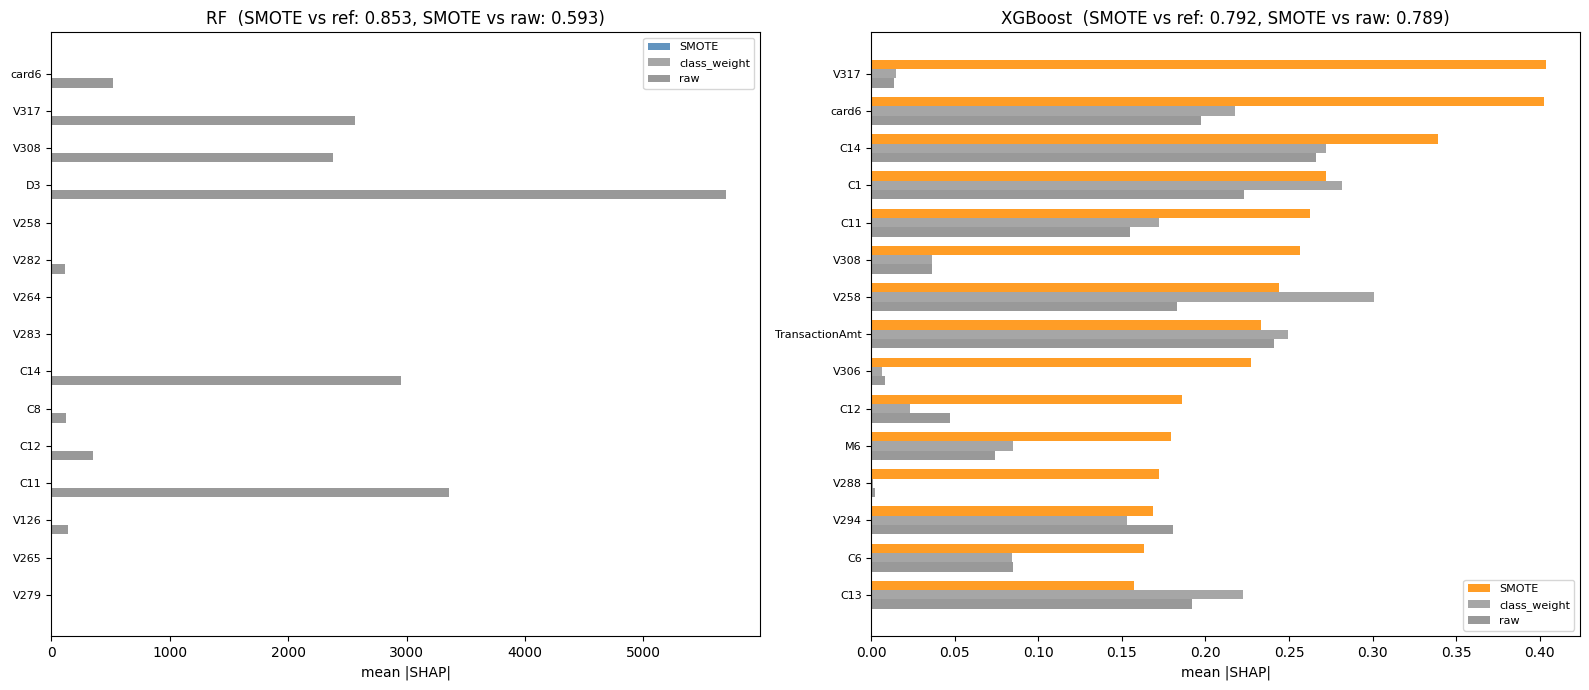

In [15]:
os.makedirs('../results/figures', exist_ok=True)

# three way comparison: top 15 features per model
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, s_imp, r_imp, rw_imp, name, corr_r, corr_rw, col in [
    (axes[0], rf_smote_imp,  rf_ref_imp,  rf_raw_imp,
     'RF',      corr_rf_smote_ref,  corr_rf_smote_raw,  'steelblue'),
    (axes[1], xgb_smote_imp, xgb_ref_imp, xgb_raw_imp,
     'XGBoost', corr_xgb_smote_ref, corr_xgb_smote_raw, 'darkorange')
]:
    feats = s_imp.nlargest(15).index
    y = np.arange(len(feats))
    ax.barh(y - 0.25, s_imp[feats],  0.25, label='SMOTE',        color=col,     alpha=0.85)
    ax.barh(y,        r_imp[feats],  0.25, label='class_weight',  color='grey',  alpha=0.7)
    ax.barh(y + 0.25, rw_imp[feats], 0.25, label='raw',           color='black', alpha=0.4)
    ax.set_yticks(y)
    ax.set_yticklabels(feats, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('mean |SHAP|')
    ax.set_title(f'{name}  (SMOTE vs ref: {corr_r:.3f}, SMOTE vs raw: {corr_rw:.3f})')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../results/figures/smote_distortion.png', dpi=150, bbox_inches='tight')
plt.show()

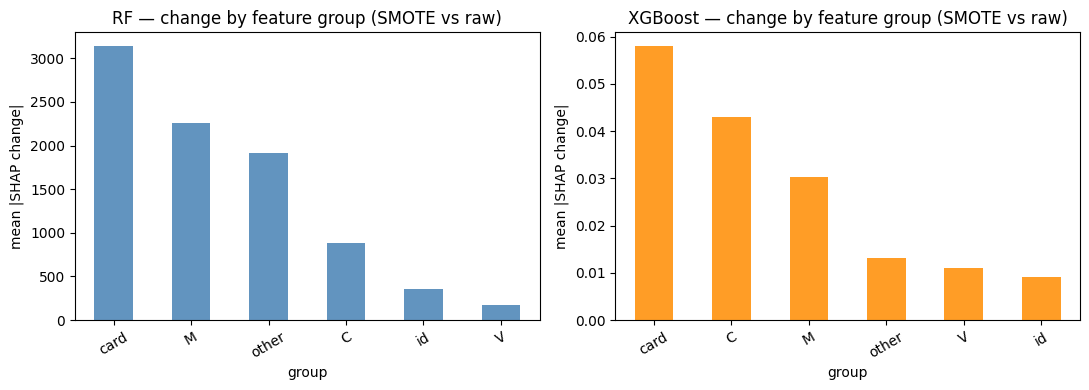

In [16]:
# feature group change: SMOTE vs raw
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

rf_change_df.groupby('group')['change'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[0], color='steelblue', alpha=0.85)
axes[0].set_title('RF — change by feature group (SMOTE vs raw)')
axes[0].set_ylabel('mean |SHAP change|')
axes[0].tick_params(axis='x', rotation=30)

xgb_change_df.groupby('group')['change'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='darkorange', alpha=0.85)
axes[1].set_title('XGBoost — change by feature group (SMOTE vs raw)')
axes[1].set_ylabel('mean |SHAP change|')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../results/figures/smote_distortion_by_group.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
os.makedirs('../results/metrics', exist_ok=True)

pd.DataFrame({
    'model':           ['RF',                    'RF',                   'RF',
                        'XGBoost',               'XGBoost',              'XGBoost'],
    'comparison':      ['SMOTE vs class_weight', 'SMOTE vs raw',         'class_weight vs raw',
                        'SMOTE vs class_weight', 'SMOTE vs raw',         'class_weight vs raw'],
    'spearman':        [corr_rf_smote_ref,        corr_rf_smote_raw,      corr_rf_ref_raw,
                        corr_xgb_smote_ref,       corr_xgb_smote_raw,     corr_xgb_ref_raw],
    'mean_rank_shift': [rf_shift_smote_ref.mean(), rf_shift_smote_raw.mean(), rf_shift_ref_raw.mean(),
                        xgb_shift_smote_ref.mean(), xgb_shift_smote_raw.mean(), xgb_shift_ref_raw.mean()]
}).to_csv('../results/metrics/smote_distortion_summary.csv', index=False)

print('saved.')

saved.


## Case Study: One Fraud Instance, Three Explanations

Finding a fraud transaction where all three XGBoost versions give high confidence (>0.7). Comparing what each model thinks is driving the prediction.

In [18]:
test_fraud_indices = y_test[y_test == 1].index.tolist()

chosen_idx = None
for idx in test_fraud_indices:
    instance = X_test.loc[[idx]]
    p_smote = xgb_smote.predict_proba(instance)[:, 1][0]
    p_ref   = xgb_ref.predict_proba(instance)[:, 1][0]
    p_raw   = xgb_raw.predict_proba(instance)[:, 1][0]
    if p_smote > 0.7 and p_ref > 0.7 and p_raw > 0.7:
        chosen_idx = idx
        print(f'instance index : {idx}')
        print(f'SMOTE prob     : {p_smote:.4f}')
        print(f'class_weight   : {p_ref:.4f}')
        print(f'raw prob       : {p_raw:.4f}')
        break

# fallback to 0.5 threshold if nothing found at 0.7
if chosen_idx is None:
    print('no instance with all three > 0.7, lowering threshold to 0.5')
    for idx in test_fraud_indices:
        instance = X_test.loc[[idx]]
        p_smote = xgb_smote.predict_proba(instance)[:, 1][0]
        p_ref   = xgb_ref.predict_proba(instance)[:, 1][0]
        p_raw   = xgb_raw.predict_proba(instance)[:, 1][0]
        if p_smote > 0.5 and p_ref > 0.5 and p_raw > 0.5:
            chosen_idx = idx
            print(f'instance index : {idx}')
            print(f'SMOTE prob     : {p_smote:.4f}')
            print(f'class_weight   : {p_ref:.4f}')
            print(f'raw prob       : {p_raw:.4f}')
            break

instance index : 141
SMOTE prob     : 0.8035
class_weight   : 0.9883
raw prob       : 0.9700


In [ ]:
chosen_instance = X_test.loc[[chosen_idx]]

smote_exp = shap.TreeExplainer(xgb_smote)
ref_exp   = shap.TreeExplainer(xgb_ref)
raw_exp   = shap.TreeExplainer(xgb_raw)

sv_smote = smote_exp.shap_values(chosen_instance, check_additivity=False)
sv_ref   = ref_exp.shap_values(chosen_instance,   check_additivity=False)
sv_raw   = raw_exp.shap_values(chosen_instance,   check_additivity=False)

def get_shap_series(sv, cols):
    if isinstance(sv, list): sv = sv[1]
    return pd.Series(sv[0], index=cols)

cols = X_test.columns
s_smote = get_shap_series(sv_smote, cols)
s_ref   = get_shap_series(sv_ref,   cols)
s_raw   = get_shap_series(sv_raw,   cols)

print('SMOTE - top 10 local SHAP:')
print(s_smote.abs().nlargest(10))
print()
print('class_weight — top 10:')
print(s_ref.abs().nlargest(10))
print()
print('raw — top 10:')
print(s_raw.abs().nlargest(10))

SMOTE — top 10 local SHAP:
C12      0.951226
C11      0.546145
V258     0.526989
V282     0.480725
C1       0.474130
D3       0.391101
V317     0.319041
card6    0.297503
card2    0.278431
V279     0.230966
dtype: float32

class_weight — top 10:
C1               0.960659
V258             0.931216
V294             0.521684
V201             0.357817
C12              0.344362
C8               0.340253
TransactionID    0.324015
C11              0.288917
V261             0.215276
card6            0.215173
dtype: float32

raw — top 10:
C12      1.021577
V258     0.801550
C1       0.775971
C11      0.560138
V294     0.432451
C8       0.383046
V201     0.362241
card3    0.305998
card6    0.238297
C7       0.231092
dtype: float32


### Masking test

V306 entered the SMOTE top-10 in the earlier version of this analysis. Testing whether masking it changes the prediction, and whether the raw model reacts the same way.

In [20]:
base_smote = xgb_smote.predict_proba(chosen_instance)[:, 1][0]
base_ref   = xgb_ref.predict_proba(chosen_instance)[:, 1][0]
base_raw   = xgb_raw.predict_proba(chosen_instance)[:, 1][0]

# which features are in SMOTE top-10 but not raw
smote_top10 = set(s_smote.abs().nlargest(10).index)
raw_top10   = set(s_raw.abs().nlargest(10).index)
smote_only  = smote_top10 - raw_top10
print(f'In SMOTE top-10 but not raw top-10: {smote_only}')
print()

In SMOTE top-10 but not raw top-10: {'V282', 'V317', 'card2', 'V279', 'D3'}



In [21]:
# mask V306
if 'V306' in chosen_instance.columns:
    x_v306 = chosen_instance.copy()
    x_v306['V306'] = 0

    print('After masking V306 to 0:')
    print(f'  SMOTE:        {base_smote:.4f} -> {xgb_smote.predict_proba(x_v306)[:,1][0]:.4f}  '
          f'(change: {xgb_smote.predict_proba(x_v306)[:,1][0] - base_smote:+.4f})')
    print(f'  class_weight: {base_ref:.4f}   -> {xgb_ref.predict_proba(x_v306)[:,1][0]:.4f}  '
          f'(change: {xgb_ref.predict_proba(x_v306)[:,1][0] - base_ref:+.4f})')
    print(f'  raw:          {base_raw:.4f}   -> {xgb_raw.predict_proba(x_v306)[:,1][0]:.4f}  '
          f'(change: {xgb_raw.predict_proba(x_v306)[:,1][0] - base_raw:+.4f})')

After masking V306 to 0:
  SMOTE:        0.8035 -> 0.8517  (change: +0.0482)
  class_weight: 0.9883   -> 0.9881  (change: -0.0002)
  raw:          0.9700   -> 0.9720  (change: +0.0020)


In [22]:
# mask V70
if 'V70' in chosen_instance.columns:
    x_v70 = chosen_instance.copy()
    x_v70['V70'] = 0

    print('After masking V70 to 0:')
    print(f'  SMOTE:        {base_smote:.4f} -> {xgb_smote.predict_proba(x_v70)[:,1][0]:.4f}  '
          f'(change: {xgb_smote.predict_proba(x_v70)[:,1][0] - base_smote:+.4f})')
    print(f'  class_weight: {base_ref:.4f}   -> {xgb_ref.predict_proba(x_v70)[:,1][0]:.4f}  '
          f'(change: {xgb_ref.predict_proba(x_v70)[:,1][0] - base_ref:+.4f})')
    print(f'  raw:          {base_raw:.4f}   -> {xgb_raw.predict_proba(x_v70)[:,1][0]:.4f}  '
          f'(change: {xgb_raw.predict_proba(x_v70)[:,1][0] - base_raw:+.4f})')

After masking V70 to 0:
  SMOTE:        0.8035 -> 0.8035  (change: +0.0000)
  class_weight: 0.9883   -> 0.9883  (change: +0.0000)
  raw:          0.9700   -> 0.9700  (change: +0.0000)


## Summary table

In [23]:
summary = pd.DataFrame({
    'model':           ['RF',                    'RF',                   'RF',
                        'XGBoost',               'XGBoost',              'XGBoost'],
    'comparison':      ['SMOTE vs class_weight', 'SMOTE vs raw',         'class_weight vs raw',
                        'SMOTE vs class_weight', 'SMOTE vs raw',         'class_weight vs raw'],
    'spearman':        [corr_rf_smote_ref,        corr_rf_smote_raw,      corr_rf_ref_raw,
                        corr_xgb_smote_ref,       corr_xgb_smote_raw,     corr_xgb_ref_raw],
    'mean_rank_shift': [rf_shift_smote_ref.mean(), rf_shift_smote_raw.mean(), rf_shift_ref_raw.mean(),
                        xgb_shift_smote_ref.mean(), xgb_shift_smote_raw.mean(), xgb_shift_ref_raw.mean()]
})

print(summary.round(3).to_string(index=False))

  model            comparison  spearman  mean_rank_shift
     RF SMOTE vs class_weight     0.853            36.95
     RF          SMOTE vs raw     0.593            83.25
     RF   class_weight vs raw     0.659            47.25
XGBoost SMOTE vs class_weight     0.792            50.45
XGBoost          SMOTE vs raw     0.789            52.25
XGBoost   class_weight vs raw     0.878             2.20
